In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv')

In [ ]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [ ]:
df.shape

(2000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [ ]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [ ]:
df.isnull().sum() #checking the missing data

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols = [
    'batch_id',
    'instructor_id',
    'course_id'
]

In [ ]:
numerical_cols = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]

<Axes: ylabel='Frequency'>

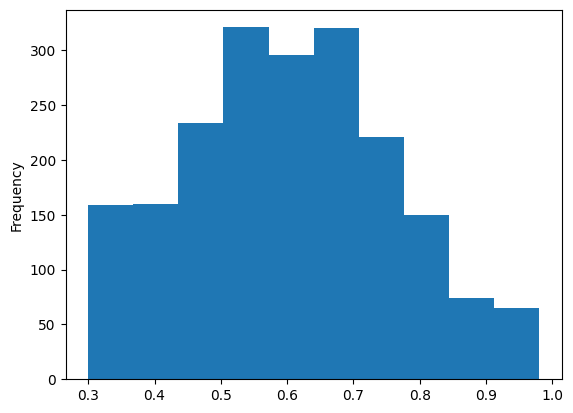

In [ ]:
df['completion_rate'].plot(kind = 'hist')

<Axes: ylabel='Density'>

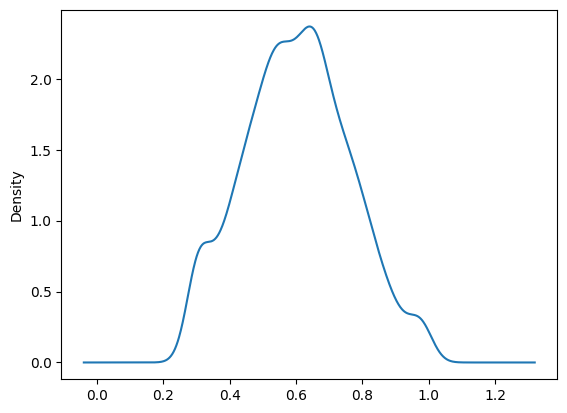

In [ ]:
df['completion_rate'].plot(kind = 'kde')

In [ ]:
df['completion_rate'].skew()

np.float64(0.10929776272113688)

<Axes: >

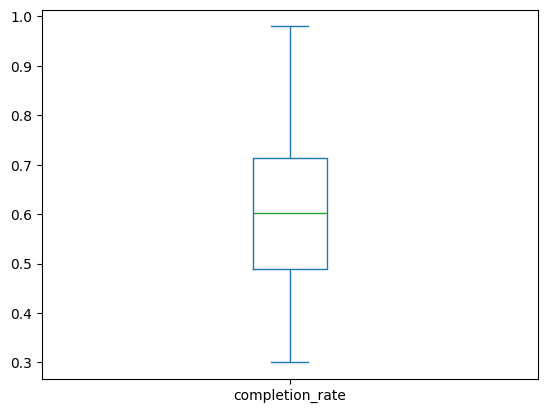

In [ ]:
df['completion_rate'].plot(kind = 'box')



*   Very less left skew
*   No outliers present


*   skewness is good 0.10





<Axes: ylabel='Frequency'>

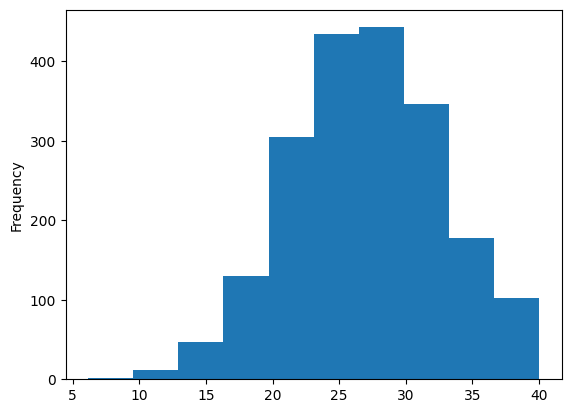

In [ ]:
df['avg_score_improvement'].plot(kind = 'hist')

<Axes: ylabel='Density'>

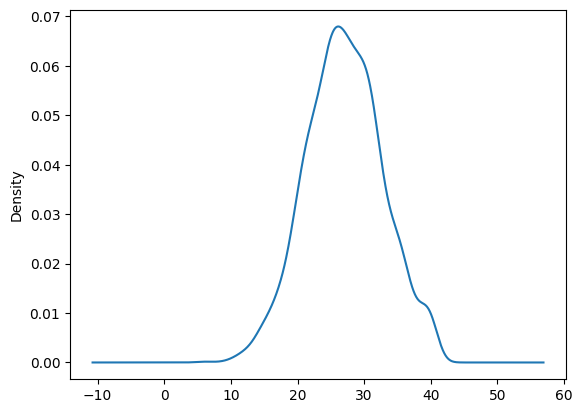

In [ ]:
df['avg_score_improvement'].plot(kind = 'kde')

In [ ]:
df['avg_score_improvement'].skew()

np.float64(-0.003487026893914137)

<Axes: >

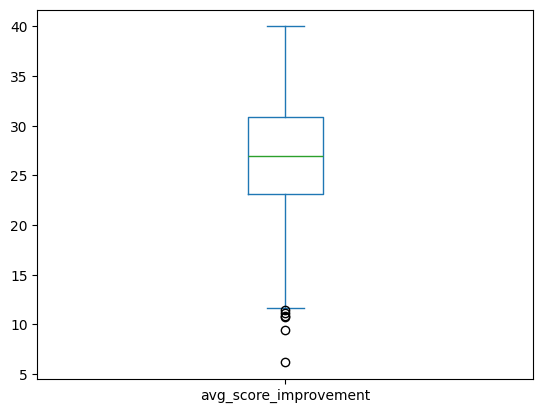

In [ ]:
df['avg_score_improvement'].plot(kind = 'box')

In [ ]:
# some outliers present
# slightly left skewed

**similarly we can check for rest of the numerical colomn**

Since the dataset does not provide a predefined effectiveness label, I define an instructor as effective if they
Help learners complete the course




*  Improve learners' knowledge
* Maintain high learner engagement
* Receive positive learner feedback
* Keep dropout rates low



In [ ]:
df["effectiveness_score"] = (
    0.25 * df["completion_rate"]
    + 0.20 * df["avg_score_improvement"]
    + 0.15 * df["avg_quiz_score"]
    + 0.10 * df["avg_watch_time"]
    + 0.10 * df["assignment_submission_rate"]
    + 0.05 * df["forum_activity_rate"]
    + 0.10 * df["avg_feedback_score"]
    + 0.05 * df["feedback_response_rate"]
    - 0.20 * df["dropout_rate"]
)
# i defined weights by intutive

In [ ]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)
#Instead of predicting a continuous score, I divide instructors into three categories using equal-frequency bins (qcut)

In [ ]:
df["effectiveness_tier"]

,effectiveness_tier
0,Low
1,Medium
2,Low
3,High
4,High
...,...
1995,Low
1996,High
1997,Medium
1998,Medium


In [ ]:
#Since each instructor may teach multiple batches, the data is aggregated from the batch level to the instructor level
#For each instructor
#mean of all numerical features.
#number of batches taught
#assign the instructor's effectiveness tier based on the average effectiveness score across batches.
#i choose mean because it summarizes an instructor's overall teaching performance across all batches while reducing the effect of individual batch fluctuations
# other aggregation methods (such as median, standard deviation, minimum, or maximum) could be useful if the business wants to study consistency or variability in instructor performance


In [ ]:
agg_dict = {
    'completion_rate':'mean',
    'avg_score_improvement':'mean',
    'avg_quiz_score':'mean',
    'dropout_rate':'mean',
    'avg_watch_time':'mean',
    'assignment_submission_rate':'mean',
    'forum_activity_rate':'mean',
    'avg_feedback_score':'mean',
    'feedback_response_rate':'mean',
    'effectiveness_score':'mean'
}
instructor_df = df.groupby('instructor_id').agg(agg_dict)


In [ ]:
instructor_df['batch_count'] = df.groupby('instructor_id').size()

In [ ]:
instructor_df['batch_count']

,batch_count
instructor_id,
I_001,25
I_002,20
I_003,18
I_004,17
I_005,19
...,...
I_116,17
I_117,19
I_118,19


In [ ]:
instructor_df.reset_index(inplace=True)
instructor_df

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,17.823060,25
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,19.076284,20
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,19.039574,18
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,16.849753,17
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,20.226279,19
...,...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.597106,26.029714,78.640236,0.412782,0.761489,0.660695,0.274891,4.091469,0.719787,17.669797,17
116,I_117,0.691715,28.430884,80.981607,0.312481,0.793272,0.814243,0.265179,4.305839,0.713759,18.584133,19
117,I_118,0.820753,32.636791,87.071798,0.202034,0.773422,0.829285,0.258419,4.641986,0.868611,20.433730,19
118,I_119,0.600597,25.159349,80.735733,0.399761,0.774830,0.766803,0.227028,4.315403,0.759761,17.847470,19


In [ ]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low','Medium','High']
)

In [ ]:
instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count,effectiveness_tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,17.823060,25,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,19.076284,20,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,19.039574,18,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,16.849753,17,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,20.226279,19,High


In [ ]:
X = instructor_df.drop(
    columns=[
        'instructor_id',
        'effectiveness_score',
        'effectiveness_tier'
    ]
)
# i have removed effectiveness_score due to data leakage
# i have removed instructor_id because it just label it doesnt tell us the quality of teaching

In [ ]:
y = instructor_df['effectiveness_tier']

In [ ]:
X.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
0,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,25
1,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,20
2,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,18
3,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,17
4,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19


In [ ]:
y.head()

,effectiveness_tier
0,Medium
1,High
2,High
3,Low
4,High


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.head()
# every time i run the notebook, i will get the same train-test split so i used random_state

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
16,0.637958,26.654082,82.575478,0.352600,0.796474,0.717645,0.257556,4.441904,0.763940,24
12,0.805156,30.605427,84.711235,0.190718,0.791646,0.775788,0.271185,4.450021,0.828494,17
68,0.597170,25.648027,76.444378,0.428536,0.797911,0.794091,0.208108,4.264269,0.805582,16
118,0.600597,25.159349,80.735733,0.399761,0.774830,0.766803,0.227028,4.315403,0.759761,19
110,0.627266,27.589007,78.530410,0.382714,0.811488,0.792901,0.244687,4.151713,0.763181,22


In [ ]:
X.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.602577,27.081173,77.816949,0.394890,0.775987,0.751371,0.250760,4.204834,0.734985,16.666667
std,0.132049,3.262537,5.203223,0.127827,0.048667,0.059035,0.038249,0.184735,0.061948,4.582270
min,0.313393,18.792529,62.635548,0.068522,0.655381,0.559471,0.126935,3.733388,0.589527,7.000000
25%,0.524226,24.794550,74.299329,0.319625,0.745444,0.714699,0.228253,4.091261,0.688954,13.750000
50%,0.599075,27.186671,78.420367,0.399884,0.779371,0.753619,0.249723,4.203793,0.742063,17.000000
75%,0.676031,29.094976,80.754386,0.478089,0.804021,0.788984,0.273528,4.329868,0.784232,19.000000
max,0.940783,34.856747,91.071769,0.664304,0.903739,0.924766,0.343266,4.641986,0.891873,31.000000


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Imputation
trf1 = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='median'), num_cols)
])

# Feature Selection
trf2 = SelectKBest(score_func=f_classif, k='all')

# Model
trf3 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [ ]:
pipe_rf = Pipeline([
    ('imputer', trf1),
    ('feature_selection', trf2),
    ('classifier', trf3)
])

In [ ]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('imputer',
                 ColumnTransformer(transformers=[('imputer',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['completion_rate', 'avg_score_improvement', 'avg_quiz_score',
       'dropout_rate', 'avg_watch_time', 'assignment_submission_rate',
       'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate',
       'batch_count'],
      dtype='object'))])),
                ('feature_selection', SelectKBest(k='all')),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipe_rf.predict(X_test)
y_pred

array(['Medium', 'Medium', 'Medium', 'Medium', 'High', 'Medium', 'High',
       'Medium', 'High', 'Low', 'Low', 'Low', 'High', 'Medium', 'Medium',
       'Medium', 'Medium', 'High', 'Medium', 'Medium', 'Medium', 'High',
       'High', 'Low'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7916666666666666

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# Precision, Recall, and Overall Accuracy scores
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[7 0 1]
 [0 4 4]
 [0 0 8]]

--- Classification Report ---
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.50      0.67         8
      Medium       0.62      1.00      0.76         8

    accuracy                           0.79        24
   macro avg       0.87      0.79      0.79        24
weighted avg       0.87      0.79      0.79        24



In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()

np.float64(0.9063157894736843)

In [ ]:
instructor_df["effectiveness_tier"].value_counts(normalize=True) * 100

,proportion
effectiveness_tier,
Low,33.333333
Medium,33.333333
High,33.333333


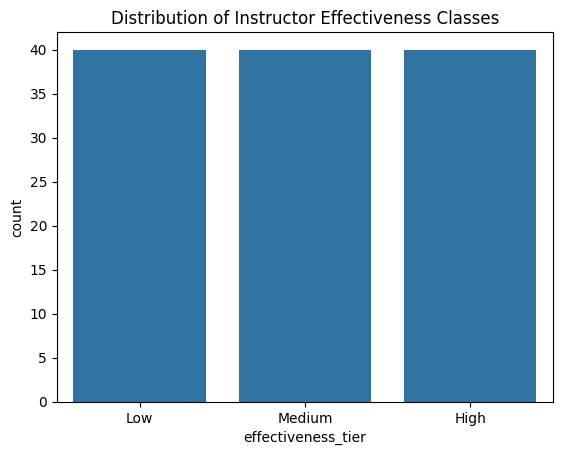

In [ ]:
sns.countplot(x="effectiveness_tier", data=instructor_df)
plt.title("Distribution of Instructor Effectiveness Classes")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pipe_rf.named_steps["classifier"].feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,avg_quiz_score,0.223729
0,completion_rate,0.223530
1,avg_score_improvement,0.170782
3,dropout_rate,0.149982
8,feedback_response_rate,0.089242
7,avg_feedback_score,0.054299
6,forum_activity_rate,0.033436
4,avg_watch_time,0.024667
5,assignment_submission_rate,0.016854
9,batch_count,0.013479


## Interpretation of Feature Importance

The Random Forest model identified **average quiz score** (22.37%) and **completion rate** (22.35%) as the two most influential features in predicting instructor effectiveness. This indicates that learner performance in assessments and successful course completion are the strongest indicators of teaching effectiveness.

The next most important features were **average score improvement** (17.08%) and **dropout rate** (15.00%). These results suggest that effective instructors not only help students improve academically but also keep them engaged throughout the course.

Features related to learner feedback, such as **feedback response rate** and **average feedback score**, had a moderate influence on the model. In contrast, **forum activity**, **watch time**, **assignment submission rate**, and **batch count** contributed relatively little to the predictions.



The model can be integrated into an instructor analytics dashboard to monitor teaching effectiveness in real time. It can identify instructors who may need additional support, recommend personalized training, monitor course quality, and help managers make data-driven **decisions**

## **Which features were most predictive of instructor effectiveness?**
The Random Forest model identified **average quiz score** and **completion rate** as the two most important features, each contributing about 22% to the prediction. This suggests that instructors whose students perform well in quizzes and successfully complete their courses are more likely to be effective.

The next most influential features were **average score improvement** and **dropout rate**. These indicate that helping students improve academically while keeping dropout rates low is also a strong indicator of teaching effectiveness.



## **Are there any potential confounding variables?**

Yes. Some factors that influence instructor effectiveness are not available in the dataset. For example, course difficulty, student background, prior knowledge, class size, teaching experience, and course subject may affect learner performance independently of the instructor's teaching ability.

Since these variables are not included, the model may attribute some of their effects to the available features, which could influence the accuracy of the predictions.

## **What additional data would improve the model?**

The model could be improved by including additional information such as instructor teaching experience, student IQ, prior academic performance, course difficulty level, class size, attendance records, and learner retention over time.

These features would provide more context and help the model distinguish between instructor performance and external factors that affect learning outcomes.

### **How could these insights be used in an EdTech product?**

The insights from the model can be used to build an instructor performance dashboard that tracks key teaching metrics and predicts instructor effectiveness.

The platform can identify instructors who may need additional support, recommend personalized training programs, monitor course quality, and recognize high-performing instructors. These insights can also help academic managers make decisions to improve learner engagement and course completion rates.


## **What are the limitations of this analysis?**

One limitation of this analysis is that the instructor effectiveness score was created using manually assigned weights rather than historical labels or expert evaluations. As a result, the target variable reflects assumptions made during feature engineering.

also , the dataset does not include factors such as course difficulty, student background, or instructor experience, which may also influence teaching effectiveness.